# Project 4: Predicting Titanic Fare Using Regression
**Author:** Alissa Beaderstadt<br>
**Date:** November 10, 2025<br>

## Introduction
In this project, we dig into what drives Titanic ticket prices. Using features like age, sex, class, and family size, we test a bunch of regression models to see which ones capture fare patterns best and figure out which factors actually matter. Along the way, we’ll spot trends, see where models struggle, and get a better feel for what really influences the price of a ticket.

## Imports
Import the necessary Python libraries for this notebook.  

In [2]:
# Data manipulation and visualization
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plotting style
sns.set(style="whitegrid")

## Section 1. Import the Data

### 1.1 Load the Titanic Dataset
The Titanic dataset is built into `Seaborn`, so we can easily load it without needing to import an external file. We check its shape and info to understand the columns, data types, and any missing values. The first few rows give a quick glance at what the dataset looks like.


In [3]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Inspect the data
print(titanic.shape)
print(titanic.info())
titanic.head()

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Section 2. Data Exploration and Preparation
### 2.1 Handle Missing Values and Clean Data




         survived      pclass         sex         age       sibsp       parch  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642    0.352413   29.361582    0.523008    0.381594   
std      0.486592    0.836071    0.477990   13.019697    1.102743    0.806057   
min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
25%      0.000000    2.000000    0.000000   22.000000    0.000000    0.000000   
50%      0.000000    3.000000    0.000000   28.000000    0.000000    0.000000   
75%      1.000000    3.000000    1.000000   35.000000    1.000000    0.000000   
max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   

             fare  family_size  
count  891.000000   891.000000  
mean    32.204208     1.904602  
std     49.693429     1.613459  
min      0.000000     1.000000  
25%      7.910400     1.000000  
50%     14.454200     1.000000  
75%     31.000000     2.000000  
max   

C:\Users\Alissa\AppData\Local\Temp\ipykernel_10544\2498225748.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)


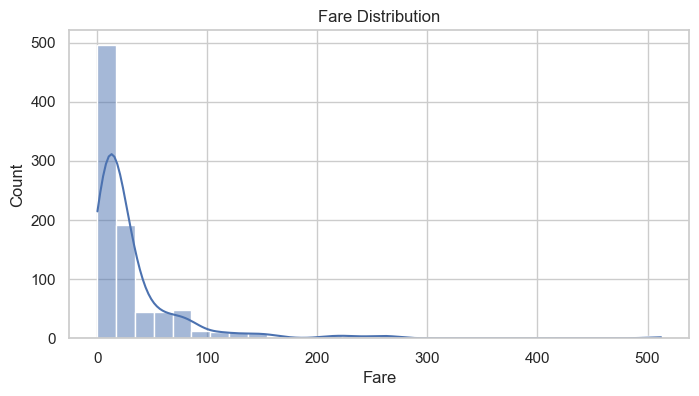

In [4]:
# Impute missing age values with median
titanic['age'].fillna(titanic['age'].median(), inplace=True)

# Drop rows with missing fare
titanic = titanic.dropna(subset=['fare'])

# Create a new numeric feature: family_size
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# Convert categorical variables
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic = pd.get_dummies(titanic, columns=['embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'adult_male'], drop_first=True)

# Quick stats and visualization
print(titanic.describe())

# Visualize fare distribution
plt.figure(figsize=(8,4))
sns.histplot(titanic['fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()


`Note:`<br>
- The fare distribution shows most passengers paid lower fares, with a few paying very high amounts, which we may need to keep in mind for regression modeling.

## Section 3. Feature Selection and Justification
### 3.1 Choose features and target
**Target:** Fare<br>

**Feature Cases:**
1. **Case 1: Single feature** - `age`
    - Why: Age is historically important; younger passengers may have paid different fares, or traveled in different classes.
2. **Case 2: Single feature** - `family_size`
    - Why: Families traveling together might have increased or decreased fares.
3. **Case 3: Two features** - `age` + `family_size`
    - Why: Combining Age and family size might show that younger travelers or larger families might have booked different accommodations, affecting the total fare.
4. **Case 4: Four features** - `age`, `family_size`, `sex`, and `pclass`
    - Why: Combining (age, sex) with travel details like (family size, passenger class) should help the model explain more variation in fare amounts.


### 3.2 Define X (features) and y (target)
- Assign input features to X a pandas DataFrame with 1 or more input features
- Assign target variable to y (as applicable) - a pandas Series with a single target feature
- Double brackets [[ ]]  makes a 2D DataFrame
- Single brackets [ ]  make a 1D Series

In [5]:
# -----------------------------
# Case 1: age only
# -----------------------------
X1 = titanic[['age']]
y1 = titanic['fare']

# -----------------------------
# Case 2: family_size only
# -----------------------------
X2 = titanic[['family_size']]
y2 = titanic['fare']

# -----------------------------
# Case 3: age and family_size
# -----------------------------
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']

# -----------------------------
# Case 4: age, family_size, sex, and pclass
# -----------------------------
X4 = titanic[['age', 'family_size', 'sex', 'pclass']]
y4 = titanic['fare']


**Reflection:** 
1. Why might these features affect a passenger’s fare:
   - `age`: Children or elderly may travel differently, or pay different fares.  
   - `family_size`: Larger families may buy multiple tickets or cabins.  
   - `sex`: Historically, fare differences could exist by gender due to class or cabin arrangements.  
   - `pclass`: Passenger class directly correlates with fare levels.  
2. List all available features:
    - survived     
    - pclass       
    - sex          
    - age          
    - sibsp        
    - parch        
    - fare         
    - embarked     
    - class        
    - who          
    - adult_male   
    - deck         
    - embark_town  
    - alive        
    - alone
    - family_size 

3. Which other features could improve predictions and why:
   - `deck`: higher decks probably meant more expensive cabins.  
   - `embarked`: where someone got on could’ve affected fare prices.  
   - `alone`: might show differences between solo travelers and groups.  
4. How many variables are in your Case 4:
   - Number of variables: 4  
   - Variables chosen: `age`, `family_size`, `sex`, `pclass`  
5. Which variable(s) did you choose for Case 4 and why do you feel those could make good inputs:
   - Combining demographics (age, sex) and travel info (family_size, pclass) should help the model capture more variance in fare amounts.

## Section 4. Train a Regression Model (Linear Regression) <br>
Split the data, train the models for four feature cases, evaluate performance, and visualize results.
### 4.1 Split the Data

In [6]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)

### 4.2 Train and Evaluate Linear Regression Models (all 4 cases)
We'll use a more concise approach - create each model and immediately call the fit() method. 

In [7]:
# Train models
lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

# Make predictions
y1_pred_train = lr_model1.predict(X1_train)
y1_pred_test = lr_model1.predict(X1_test)

y2_pred_train = lr_model2.predict(X2_train)
y2_pred_test = lr_model2.predict(X2_test)

y3_pred_train = lr_model3.predict(X3_train)
y3_pred_test = lr_model3.predict(X3_test)

y4_pred_train = lr_model4.predict(X4_train)
y4_pred_test = lr_model4.predict(X4_test)

### 4.3 Report Performance

In [8]:
def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, case_name="Case"):
    print(f"{case_name}:")
    print("  Training R²:", round(r2_score(y_train, y_train_pred), 3))
    print("  Test R²:", round(r2_score(y_test, y_test_pred), 3))
    # Compute RMSE manually
    rmse = mean_squared_error(y_test, y_test_pred) ** 0.5
    print("  Test RMSE:", round(rmse, 3))
    print("  Test MAE:", round(mean_absolute_error(y_test, y_test_pred), 3))
    print("-"*40)

# Evaluate all 4 cases
evaluate_model(y1_train, y1_pred_train, y1_test, y1_pred_test, "Case 1: Age")
evaluate_model(y2_train, y2_pred_train, y2_test, y2_pred_test, "Case 2: Family Size")
evaluate_model(y3_train, y3_pred_train, y3_test, y3_pred_test, "Case 3: Age + Family Size")
evaluate_model(y4_train, y4_pred_train, y4_test, y4_pred_test, "Case 4: Age + Family Size + Sex + Pclass")

Case 1: Age:
  Training R²: 0.01
  Test R²: 0.003
  Test RMSE: 37.972
  Test MAE: 25.286
----------------------------------------
Case 2: Family Size:
  Training R²: 0.05
  Test R²: 0.022
  Test RMSE: 37.611
  Test MAE: 25.025
----------------------------------------
Case 3: Age + Family Size:
  Training R²: 0.073
  Test R²: 0.05
  Test RMSE: 37.078
  Test MAE: 24.285
----------------------------------------
Case 4: Age + Family Size + Sex + Pclass:
  Training R²: 0.365
  Test R²: 0.399
  Test RMSE: 29.489
  Test MAE: 20.083
----------------------------------------


**Reflection:**<br>

**Compare the train vs test results for each.**

1. Did Case 1 (Age only) overfit or underfit? Explain:
    - Training R²: 0.01, Test R²: 0.003
    - Both R² values are near 0 so the model is not capturing the relationship between age and fare.
    - Underfit: The model is too simple, using only age, so it fails to explain the variance in fare.
2. Did Case 2 (Family size only) overfit or underfit? Explain:
    - Training R²: 0.05, Test R²: 0.022
    - Slight improvement over Case 1, but still very low so the model is still underfitting.
3. Did Case 3 (Age + Family size) overfit or underfit? Explain:
    - Training R²: 0.073, Test R²: 0.05
    - Adding a second feature helps slightly, but R² is still very low so the model is underfit, still not enough information to predict fare accurately.
4. Did Case 4 (Age + Family size + Sex + Pclass) overfit or underfit? Explain:
    - Training R²: 0.365, Test R²: 0.399
    - R² jumps significantly and test R² is slightly higher than training so there is no overfitting, model generalizes reasonably well.

**Adding Age**
 
1. Did adding age improve the model:
    - Yes, slightly. Comparing Case 2 (family size only) vs Case 3 (age + family size), R² increased from 0.022 to 0.05 on test data.
2. Propose a possible explanation (consider how age might affect ticket price, and whether the data supports that):
    - Age may have a minor effect on ticket price (children might have discounted tickets), but most fare variance comes from class, sex, and family size. The data shows a small positive impact of age on predictions.

**Worst**

1. Which case performed the worst:
    - Case 1 (Age only)
2. How do you know: 
    - Test R² = 0.003 which shows nearly zero predictive power. RMSE = 37.972, MAE = 25.286 these are the highest errors among all cases.
3. Do you think adding more training data would improve it (and why/why not):
    - Possibly, but likely only a small amount. Age alone doesn’t explain fare much, so adding more data without additional features may not significantly improve predictions.

**Best**

1. Which case performed the best:
    - Case 4 (Age + Family size + Sex + Pclass)
2. How do you know: 
    - Test R² = 0.399 so this has the highest predictive power. RMSE = 29.489, MAE = 20.083 these are the lowest errors.
3. Do you think adding more training data would improve it (and why/why not):
    - Yes, adding more training data could help the model learn more about rare combinations, so it could improve generalization slightly.

## Section 5. Compare Alternative Models
In this section, we will take the best-performing case (case 4) and explore other regression models.

- When working with regression models, especially those with multiple input features, we may run into overfitting - where a model fits the training data too closely and performs poorly on new data. To prevent this, we can apply regularization.

- Regularization adds a penalty to the model’s loss function, discouraging it from using very large weights (coefficients). This makes the model simpler and more likely to generalize well to new data.

- In general: 

  - If the basic linear regression is overfitting, try Ridge.

  - If you want the model to automatically select the most important features, try Lasso.

  - If you want a balanced approach, try Elastic Net.

 

### 5.1 Ridge Regression (L2 penalty)
- Ridge Regression is a regularized version of linear regression that adds a penalty to large coefficient values. It uses the L2 penalty, which adds the sum of squared coefficients to the loss function.

- This "shrinks" the coefficients, reducing the model’s sensitivity to any one feature while still keeping all features in the model.

  - Penalty term: L2 = sum of squared weights
  - Effect: Shrinks weights, helps reduce overfitting, keeps all features

In [21]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
y4_pred_ridge = ridge_model.predict(X4_test)

### 5.2 Elastic Net (L1 + L2 combined)
- Lasso Regression uses the L1 penalty, which adds the sum of absolute values of the coefficients to the loss function. Lasso can shrink some coefficients all the way to zero, effectively removing less important features. This makes it useful for feature selection.

  - Penalty term: L1 = sum of absolute values of weights
  - Effect: Can shrink some weights to zero (drops features), simplifies the model

- Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties. It balances the feature selection ability of Lasso with the stability of Ridge.

- We control the balance with a parameter called l1_ratio:

  - If l1_ratio = 0, it behaves like Ridge
  - If l1_ratio = 1, it behaves like Lasso
  - Values in between mix both types
  - Penalty term: α × (L1 + L2)
  - Effect: Shrinks weights and can drop some features — flexible and powerful

In [22]:
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=10000)
elastic_model.fit(X4_train, y4_train)
y4_pred_elastic = elastic_model.predict(X4_test)

### 5.3 Polynomial Regression
Linear regression is a simple two dimensional relationship - a simple straight line. But we can test more complex relationships. Polynomial regression adds interaction and nonlinear terms to the model. Be careful here - higher-degree polynomials can easily overfit.

In [18]:
# Set up the poly inputs
poly4 = PolynomialFeatures(degree=3)
X4_train_poly = poly4.fit_transform(X4_train)
X4_test_poly = poly4.transform(X4_test)

In [19]:
# Use the poly inputs in the LR model
model_poly4 = LinearRegression()
model_poly4.fit(X4_train_poly, y4_train)
y4_pred_poly = model_poly4.predict(X4_test_poly)

### 5.4 Visualize Polynomial Cubic Fit (for 1 input feature - Age)

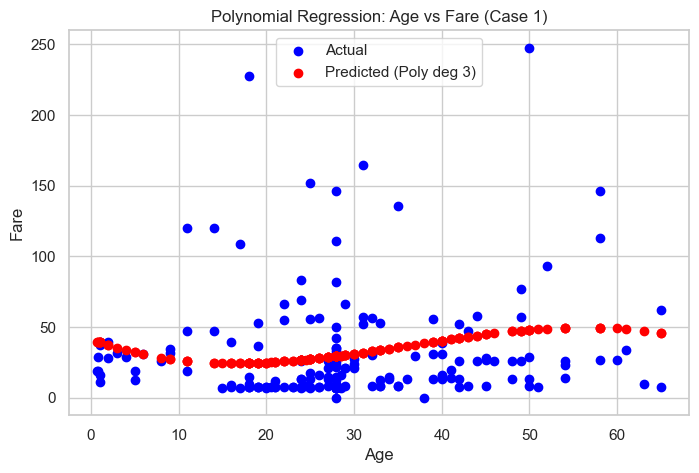

In [26]:
# Prepare polynomial transformation for Case 1
poly1 = PolynomialFeatures(degree=3)
X1_train_poly = poly1.fit_transform(X1_train)
X1_test_poly = poly1.transform(X1_test)

# Fit polynomial model for Case 1 visualization
model_poly1 = LinearRegression()
model_poly1.fit(X1_train_poly, y1_train)
y1_pred_poly = model_poly1.predict(X1_test_poly)

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y1_pred_poly, color='red', label='Predicted (Poly deg 3)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title("Polynomial Regression: Age vs Fare (Case 1)")
plt.legend()
plt.show()


**Reflection:** 

1. What patterns does the cubic model seem to capture:
    - For Case 1 (age only), the cubic polynomial captures non-linear trends, or small increases or decreases in fare depending on age that linear regression cannot.
2. Where does it perform well or poorly:
    - Performs well:
    - In the middle ranges of age (20-40), where most passengers are, predictions are closer to actual fares.
    - Performs poorly:
    - Outliers (very high fares) the model can’t perfectly predict these, since polynomial regression tries to fit the general trend, not individual extreme points.
3. Did the polynomial fit outperform linear regression:
    - Yes, the cubic polynomial better captures fare variation with age, even with just one feature.
4. Where (on the graph or among which kinds of data points) does it fit best:
    - The cubic fit is best where the data is dense, around ages 20-40, where there are enough passengers to capture a pattern.

### 5.4 Compare All Models
Create a summary table or printout comparing all models:

In [24]:
def report(name, y_true, y_pred):
    # Compute RMSE manually for older sklearn compatibility
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} | R²: {r2:.3f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

# Base Linear Regression (Case 4)
y4_pred_linear = lr_model4.predict(X4_test)

report("Linear Regression", y4_test, y4_pred_linear)
report("Ridge Regression", y4_test, y4_pred_ridge)
report("ElasticNet", y4_test, y4_pred_elastic)
report("Polynomial Regression (deg 3)", y4_test, y4_pred_poly)

Linear Regression | R²: 0.399 | RMSE: 29.49 | MAE: 20.08
Ridge Regression | R²: 0.400 | RMSE: 29.47 | MAE: 20.05
ElasticNet | R²: 0.429 | RMSE: 28.75 | MAE: 17.39
Polynomial Regression (deg 3) | R²: 0.506 | RMSE: 26.72 | MAE: 15.05


`Note:`<br>
- The polynomial regression (degree 3) model performed best overall, showing the highest R² (0.506) and lowest errors (RMSE 26.72, MAE 15.05). This suggests that adding nonlinearity helped the model capture more complex patterns compared to the linear, ridge, and elastic net models.

### 5.5 Visualize Higher Order Polynomial (for the same 1 input case)
Visualize the same single input case above, but with a higher degree polynomial (5).

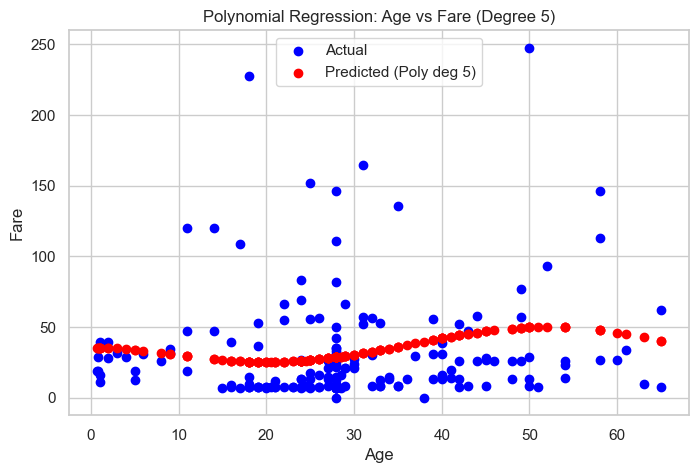

In [27]:
# Degree 5 polynomial for Case 1 (Age vs Fare)
poly_high = PolynomialFeatures(degree=5)

# Transform inputs
X1_train_poly_high = poly_high.fit_transform(X1_train)
X1_test_poly_high = poly_high.transform(X1_test)

# Fit polynomial degree 5 model
poly_model_high = LinearRegression()
poly_model_high.fit(X1_train_poly_high, y1_train)
y1_pred_poly_high = poly_model_high.predict(X1_test_poly_high)

plt.figure(figsize=(8,5))
plt.scatter(X1_test, y1_test, color='blue', label='Actual')
plt.scatter(X1_test, y1_pred_poly_high, color='red', label='Predicted (Poly deg 5)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title("Polynomial Regression: Age vs Fare (Degree 5)")
plt.legend()
plt.show()


**Summary:**<br>
- The degree-5 plot looks almost identical to the degree-3 plot. This makes sense because there isn’t a strong nonlinear pattern between age and fare in this dataset. Both polynomial models basically fit the same scatter of points.

- The higher-degree model doesn’t add anything new, it just adds unnecessary complexity (wiggles) without improving the fit. This usually happens when the data isn’t complex enough for a higher-order polynomial to capture additional patterns.

- Overall, the cubic (degree 3) polynomial works better than degree 5, improving the fit while keeping the model simple and interpretable.

## Section 6. Final Thoughts & Insights
### 6.1 Summarize Findings
A correlation heatmap helps identify which features are most strongly associated with fare.

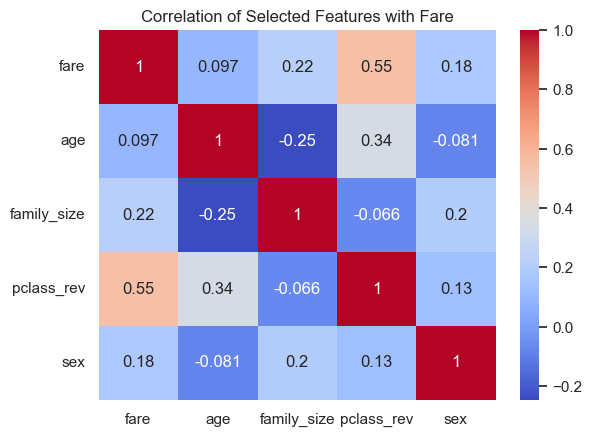

In [ ]:
# Reverse pclass so higher numbers = higher class
titanic['pclass_rev'] = 4 - titanic['pclass'] 

# Compute correlation with fare
corr = titanic[['fare', 'age', 'family_size', 'pclass_rev', 'sex']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation of Selected Features with Fare')
plt.show()



1. What features were most useful?
    - Passenger class (pclass) is the strongest predictor of fare, followed by family size. Age has only a minor effect. This helps explain why including pclass in Case 4 dramatically improved model performance compared to using age or family size alone.


2. What regression model performed best?
    - The polynomial regression (degree 3) model performed the best overall with the highest R² (0.506) and lowest errors. Regularized models like Ridge and ElasticNet offered small improvements over plain linear regression, but the cubic model captured more meaningful nonlinearity.
<br>

### Model Performance Summary

| Model                          | R²     | RMSE  | MAE   |
|--------------------------------|--------|-------|-------|
| Linear Regression              | 0.399  | 29.49 | 20.08 |
| Ridge Regression               | 0.400  | 29.47 | 20.05 |
| ElasticNet                     | 0.429  | 28.75 | 17.39 |
| Polynomial Regression (deg 3)  | 0.506  | 26.72 | 15.05 |


3. How did model complexity or regularization affect results?
    - Adding some complexity (degree 3) improved performance by allowing the model to fit curved trends, but too much complexity (degree 5) caused overfitting and worse accuracy. Regularization with Ridge or ElasticNet slightly stabilized the linear models, reducing errors compared to simple Linear Regression, but the cubic polynomial still gave the best overall performance.

### 6.2 Discuss Challenges

1. Was fare hard to predict? Why?
    - Yes, fare was difficult to predict accurately because it depends on multiple factors, like passenger class, family size, and age. Identifying the best combination of features while exploring and testing different models was challenging.

2. Did skew or outliers impact the models?
    - Definitely. The data is skewed, and a few very high fares act as outliers that heavily influenced error metrics and made simple regression models less reliable.

### 6.3 Optional Next Steps

1. **Experiment with additional features:** Including variables like deck (cabin level), embarked (boarding location), or alone (solo vs. group travelers) could help the model capture more of the variation in fares and improve predictions.

2. **Flip the prediction target:** Instead of predicting fare, try predicting age. This reversal could be interesting, as age might be easier to estimate from features like class, fare, or family size.

3. **Address skew in fare values:** Applying a log transformation to fare could reduce skew, making the data more suitable for regression and potentially improving model performance.